# Customer Churn Analysis

## Objective

The objective of this project is to analyze customer data to identify patterns behind subscription cancellations. The analysis evaluates customer activity, engagement levels, contract types, payment methods, and service usage to determine the major factors contributing to customer churn and to recommend strategies for improving customer retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Step 1: Load the Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame. Displaying the first few rows helps verify that the dataset has been imported successfully.

In [3]:
df = pd.read_csv("/content/sample_data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Dataset Information

This step examines the dimensions, column names, data types, and overall structure of the dataset before performing data cleaning and analysis.

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     704

## Step 3: Check Missing Values

Missing values can affect the quality of analysis. This step identifies columns containing missing values that need to be handled.

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Step 4: Check Duplicate Records

Duplicate records can introduce bias into the analysis. This step identifies duplicate customer records.

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


## Step 5: Remove Duplicate Records

Duplicate records are removed from the dataset to ensure each customer is represented only once.

In [9]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (7043, 21)


## Step 6: Clean the TotalCharges Column

The TotalCharges column is converted to numeric format. Invalid or missing values are replaced with the median value to maintain consistency.

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

## Step 7: Analyze Customer Churn Distribution

This step analyzes the number of customers who stayed and those who churned. A bar chart is used to visualize the distribution.

Churn
No     5174
Yes    1869
Name: count, dtype: int64


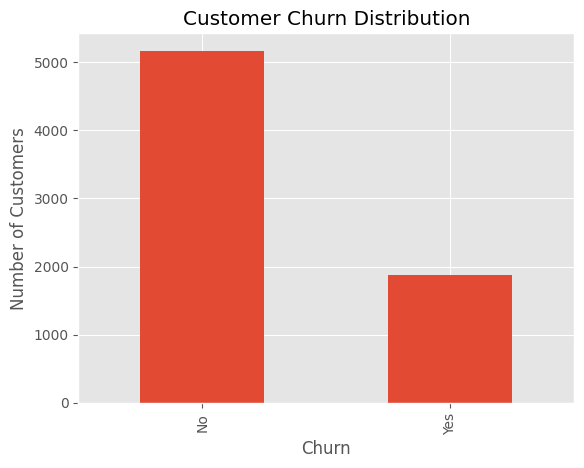

In [12]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Step 8: Analyze Contract Type and Churn

This analysis compares customer churn across different contract types to understand its impact on customer retention.

In [13]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


## Step 9: Analyze Monthly Charges

This step compares the average monthly charges of customers who churned and those who remained.

In [14]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


## Step 10: Analyze Customer Tenure

Customer tenure indicates how long customers stay with the company. This analysis compares the average tenure of churned and retained customers.

In [15]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


## Step 11: Analyze Internet Service

This step compares customer churn across different internet service types.

In [16]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


## Step 12: Analyze Payment Methods

This analysis examines whether different payment methods are associated with higher customer churn.

In [17]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 13: Save the Cleaned Dataset

The cleaned and processed dataset is exported as a CSV file for future analysis and reporting.

In [18]:
df.to_csv("cleaned_customer_churn.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
